## 1. Business Understanding
The objectives are
- to learn to use linear regression for predicting continuously varying target variables  
- to learn to use logistic regression for binary classification  
- to learn to estimate the relative importance of input features

We'll be building a model with linear and logical regression to predict real estate pricing in taipei, taiwan to achieve the objectives

## 2. Data Understanding

We'll be using dataset found here https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import mean_absolute_error, confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

### Load Data

In [2]:
from ucimlrepo import fetch_ucirepo 
  
real_estate_valuation = fetch_ucirepo(id=477) 
  
X = real_estate_valuation.data.features 
y = real_estate_valuation.data.targets 
  
print(real_estate_valuation.metadata) 
print(real_estate_valuation.variables) 

{'uci_id': 477, 'name': 'Real Estate Valuation', 'repository_url': 'https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set', 'data_url': 'https://archive.ics.uci.edu/static/public/477/data.csv', 'abstract': 'The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. ', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 414, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y house price of unit area'], 'index_col': ['No'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C5J30W', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 373, 'type': 'NATIVE', 'title': 'Building real estate valuation models with comparative approach through case-based reasoning', 'authors': 'I. Yeh

### Basic Information

We have 6 features, including  
`X1 transaction date`  
`X2 house age`  
`X3 distance to the nearest MRT station`  
`X4 number of convenience stores`  
`X5 latitude`  
`X6 longitude`  

X1=the transaction date (for example, 2013.250=2013 March, 2013.500=2013 June, etc.)  
X2=the house age (unit: year)  
X3=the distance to the nearest MRT station (unit: meter)  
X4=the number of convenience stores in the living circle on foot (integer)  
X5=the geographic coordinate, latitude. (unit: degree)  
X6=the geographic coordinate, longitude. (unit: degree)  

We also have target `house price of unit area`

In [3]:
X.info()
X.describe()
X.dtypes

y.info()
y.describe()

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 19.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 1 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Y house price of unit area  414 non-null    float64
dtypes: float64(1)
memory usage: 3.4 KB


,Y house price of unit area
count,414.000000
mean,37.980193
std,13.606488
min,7.600000
25%,27.700000
50%,38.450000
75%,46.600000
max,117.500000


## 3. Data Preparation

### Check Missing Values

Theres no empty values

In [4]:
X.isnull().sum()

X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
dtype: int64

### Clean Data

We can see that `number of convenience stores` is `int64`, lets convert that to `float64` so our scaler works

In [5]:
X.dtypes

X1 transaction date                       float64
X2 house age                              float64
X3 distance to the nearest MRT station    float64
X4 number of convenience stores             int64
X5 latitude                               float64
X6 longitude                              float64
dtype: object

In [6]:
X['X4 number of convenience stores'] = X['X4 number of convenience stores'].astype('float64')
X.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10.0,24.98298,121.54024
1,2012.917,19.5,306.59470,9.0,24.98034,121.53951
2,2013.583,13.3,561.98450,5.0,24.98746,121.54391
3,2013.500,13.3,561.98450,5.0,24.98746,121.54391
4,2012.833,5.0,390.56840,5.0,24.97937,121.54245


### Cleaning up column naming

In [7]:
for col in X.columns:
    X = X.rename(columns={col: col.split(' ',1)[1]})
X.dtypes

transaction date                       float64
house age                              float64
distance to the nearest MRT station    float64
number of convenience stores           float64
latitude                               float64
longitude                              float64
dtype: object

### Splitting data

We need targets as absolute for linear and binary for logistic so lets create `y_logistic` and create a split using both 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)

mean_price = y_train["Y house price of unit area"].mean()
y_train_log = (y_train["Y house price of unit area"] > mean_price).astype(int)
y_test_log = (y_test["Y house price of unit area"] > mean_price).astype(int)

X_train_log = X_train
X_test_log = X_test

## 4. Modeling

### Linear regression model

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept: {model.intercept_[0]:.2f}")
print("Coefficients:")
for i, coef in enumerate(model.coef_[0], start=1):
    print(f"b{i}: {coef:.4f}")

Intercept: -14934.22
Coefficients:
b1: 5.1021
b2: -0.2745
b3: -0.0041
b4: 1.1824
b5: 239.5421
b6: -10.4970


### Mean Absolute Error

In [10]:
preds = model.predict(X_test)
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, preds))

Mean absolute error: 5.63


### Residual chart

From our test ample size only being around 100 (25% of original dataset), our residual chart doesnt exactly look like normal distribution but extrapolating we can see its starting to shape up like one.

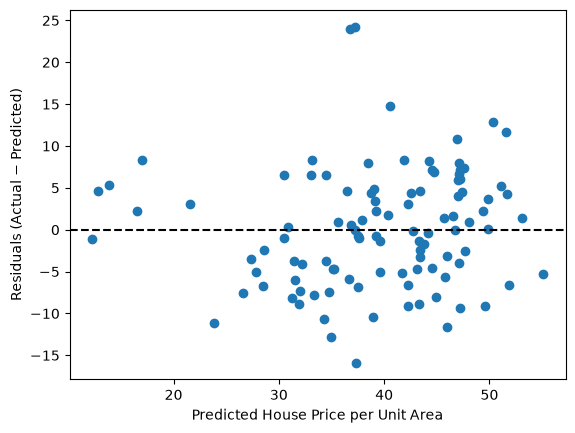

In [11]:
residuals = y_test - preds

plt.scatter(preds, residuals)
plt.xlabel('Predicted House Price per Unit Area')
plt.ylabel('Residuals (Actual − Predicted)')
plt.axhline(0, color='black', linestyle='--')
plt.show()

### Logical Regression Model

First lets scale the data

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

In [13]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train_log)
y_pred = log_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test_log, y_pred))
print(classification_report(y_test_log, y_pred))

Accuracy: 0.8269230769230769
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        44
           1       0.85      0.85      0.85        60

    accuracy                           0.83       104
   macro avg       0.82      0.82      0.82       104
weighted avg       0.83      0.83      0.83       104



{'importances_mean': array([ 0.00480769,  0.00865385,  0.10576923,  0.00480769,  0.025     ,
        -0.01538462]),
 'importances_std': array([0.01565271, 0.02487023, 0.02719641, 0.01837017, 0.03445476,
        0.01153846]),
 'importances': array([[ 0.01923077,  0.        ,  0.        ,  0.01923077,  0.02884615,
          0.        ,  0.00961538, -0.00961538, -0.02884615,  0.00961538],
        [ 0.00961538,  0.02884615,  0.00961538, -0.01923077,  0.        ,
         -0.01923077,  0.03846154,  0.05769231, -0.01923077,  0.        ],
        [ 0.08653846,  0.05769231,  0.08653846,  0.125     ,  0.125     ,
          0.13461538,  0.06730769,  0.125     ,  0.13461538,  0.11538462],
        [-0.01923077, -0.00961538,  0.01923077,  0.        ,  0.01923077,
          0.00961538, -0.01923077, -0.00961538,  0.01923077,  0.03846154],
        [ 0.03846154,  0.03846154,  0.08653846, -0.03846154,  0.02884615,
          0.00961538,  0.03846154, -0.01923077,  0.00961538,  0.05769231],
        [-0.028

Accuracy: 0.85
Confusion Matrix:
 [[33 11]
 [ 5 55]]
Coefficients:  [[ 0.18602429 -0.74347901 -2.04893342  0.68968884  0.9722291   0.23128459]]
Intercept:  [-0.66633952]


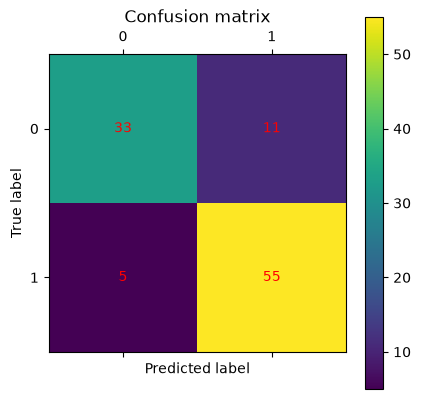

/var/folders/wv/6d453psx4ks3q_hd1g1sn8zm0000gn/T/ipykernel_49897/1862185522.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=X.columns[sorted_idx])


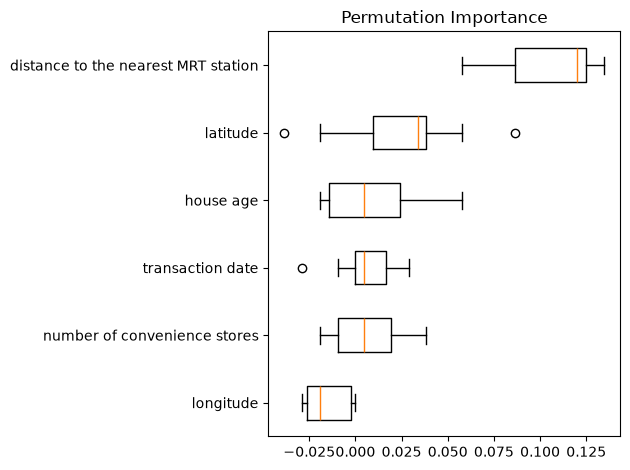

In [15]:
result = permutation_importance(log_model, X_test_scaled, y_test_log, n_repeats=10, scoring="accuracy", random_state=0, n_jobs=-1)

display(result)
sorted_idx = result.importances_mean.argsort()

y_pred = cross_val_predict(estimator=log_model, X=X_test_scaled, y=y_test_log, cv=10)

cm = confusion_matrix(y_test_log, y_pred)
accuracy = accuracy_score(y_test_log, y_pred)

print("Accuracy: %0.2f" % accuracy)
print("Confusion Matrix:\n", cm)

print("Coefficients: ",log_model.coef_)
print("Intercept: ", log_model.intercept_)


plt.matshow(cm)
plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.show()
fig, ax = plt.subplots()
ax.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=X.columns[sorted_idx])
ax.set_title("Permutation Importance")
fig.tight_layout()
plt.show()

## 5. Evaluation

### Linear Regression

From MAE we can see that the model differs 5.63 units on average from the actual sale price.

The residuals seem to be relatively close to a normal distribution, although with a test sample of only around 100 observations it is difficult to determine this with high confidence. A larger dataset would give us a better representation of the residual distribution.

The coefficients of the linear regression model were:

| Feature | Coefficient |
|---|---:|
| Transaction date | 5.1021 |
| House age | -0.2745 |
| Distance to nearest MRT station | -0.0041 |
| Number of convenience stores | 1.1824 |
| Latitude | 239.5421 |
| Longitude | -10.4970 |

### Logistic Regression

The permutation importance shows us that distance to the nearest MRT station is the most impactful feature, while latitude, house age, and transaction date had lower importance. The number of convenience stores and longitude had the lowest importance.

The confusion matrix gave us an accuracy of 82.7%, with a precision of 80% and recall of 80% for class 0, and a precision of 85% and recall of 85% for class 1.

The logistic regression coefficients were:

| Feature | Coefficient | Direction | Relative importance |
|---|---:|---|---|
| Transaction date | 0.186 | Positive | Low |
| House age | -0.743 | Negative | Moderate |
| Distance to nearest MRT station | -2.049 | Negative | High |
| Number of convenience stores | 0.690 | Positive | Moderate |
| Latitude | 0.972 | Positive | Moderate |
| Longitude | 0.231 | Positive | Low |

The coefficients show us that distance to the nearest MRT station had the biggest effect on the predicted class. Its negative coefficient means that a greater distance from an MRT station is associated with lower likelihood of being in the above average house price class. The other variables had varying positive and negative relationships with the predicted class.

## 6. Deployment / Conclusion

### Results

- The linear regression model had a MAE of 5.63 meaning that the model's predictions differed from the actual house price by around 5.63 units on average.
- The logistic regression model achieved an accuracy of 82.7% when predicting whether a house price was above or below the average training-set price.
- The most impactful feature for the logistic regression model was distance to the nearest MRT station.
- The models were able to find relationships between the property features and house prices.

### Conclusion

Overall the models were able to solve the original problem to a reasonable extent. The linear regression model could predict house prices with an average error of 5.63 units, while the logistic regression model correctly classified approximately 83% samples.  

The results also show that the distance to the nearest MRT station was an important feature when predicting whether a property had an above average price. However the dataset is relatively small so using a bigger dataset would likely improve the accuracy.